In [ ]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.5 MB/s eta 0:00:00


⏳ Sedang mengunduh dataset dan melatih model SVM (78%)... Mohon tunggu sebentar.


/tmp/ipykernel_2028/2145340663.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', palette='magma')


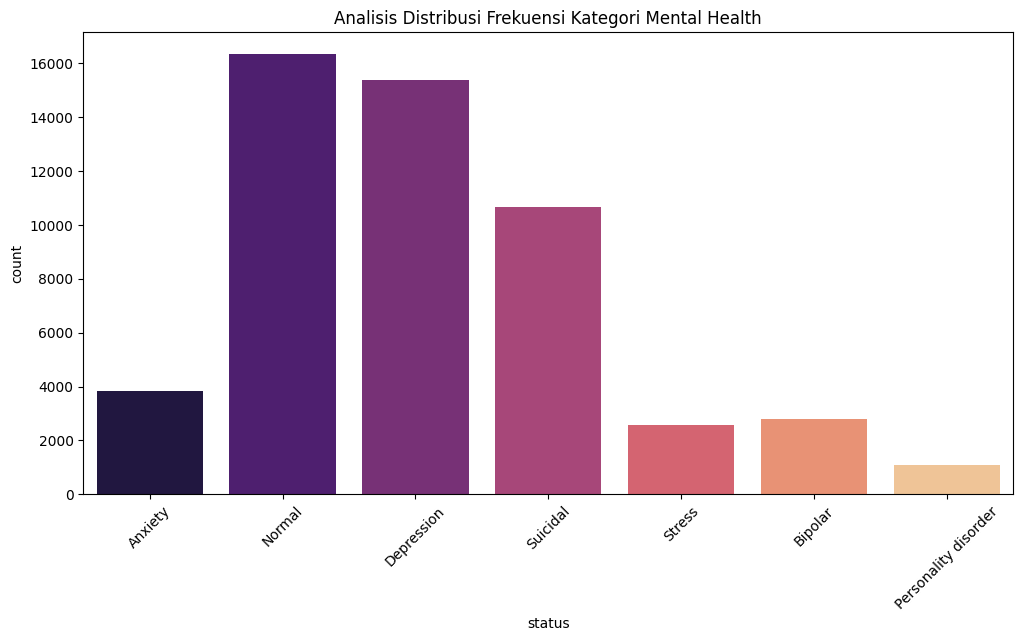

Skor Akurasi Model: 77.99%
                      precision    recall  f1-score   support

             Anxiety       0.81      0.81      0.81       755
             Bipolar       0.83      0.79      0.81       527
          Depression       0.73      0.72      0.72      3016
              Normal       0.88      0.95      0.91      3308
Personality disorder       0.83      0.64      0.72       237
              Stress       0.70      0.55      0.62       536
            Suicidal       0.68      0.66      0.67      2158

            accuracy                           0.78     10537
           macro avg       0.78      0.73      0.75     10537
        weighted avg       0.78      0.78      0.78     10537

🌐 Web Interface Berhasil Dimuat di Bawah Ini.



HTML(value='\n    <div style="background-color: #4A154B; padding: 15px; border-radius: 8px; text-align: center…

Output()

In [ ]:


import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from deep_translator import GoogleTranslator

file_id = '1DSad6sMBwa4WPN3YP8BhCpUgmb7pbXOx'
url = f'https://drive.google.com/uc?id={file_id}'

print("⏳ Sedang mengunduh dataset dan melatih model SVM (78%)... Mohon tunggu sebentar.")
df = pd.read_csv(url)
df = df.dropna(subset=['statement'])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_statement'] = df['statement'].apply(clean_text)

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['status'])

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_statement'])
y = df['label_id']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearSVC(random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='status', palette='magma')
plt.title('Analisis Distribusi Frekuensi Kategori Mental Health')
plt.xticks(rotation=45)
plt.show()

y_pred = model.predict(X_test)
score_akurasi = accuracy_score(y_test, y_pred)
print(f"Skor Akurasi Model: {score_akurasi * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("🌐 Web Interface Berhasil Dimuat di Bawah Ini.\n")

title_html = widgets.HTML(
    value="""
    <div style="background-color: #4A154B; padding: 15px; border-radius: 8px; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
        <h2 style="color: white; margin: 0;">
             Automated Mental Health Classification Engine
        </h2>
        <p style="color: #E2D6E2; margin: 5px 0 0 0; font-size: 14px;">Machine Learning Project</p>
    </div>
    """
)
input_box = widgets.Textarea(
    value='',
    placeholder='Ketikkan cerita atau luapan emosi Anda di sini (Bahasa Indonesia)...\nContoh: capeeeeekkkkk bgt sama hidup rasanya pengen ngurung diri aja...',
    description='Curhatan:',
    layout=widgets.Layout(width='100%', height='120px'),
    style={'description_width': 'initial'}
)

btn_diagnose = widgets.Button(
    description='Mulai Diagnosis AI',
    disabled=False,
    button_style='success',
    tooltip='Klik untuk menganalisis teks',
    icon='search',
    layout=widgets.Layout(width='100%', margin='10px 0px')
)

output_area = widgets.Output()


def on_button_clicked(b):
    with output_area:
        clear_output()

        user_input = input_box.value.strip()

        if not user_input:
            print("⚠️ Mohon isi kotak curhatan terlebih dahulu sebelum menekan tombol.")
            return

        input_squashed = re.sub(r'(.)\1+', r'\1\1', user_input)
        text_translated = GoogleTranslator(source='id', target='en').translate(input_squashed)
        input_clean = clean_text(text_translated)

        input_vec = tfidf.transform([input_clean])
        pred_id = model.predict(input_vec)
        final_result = le.inverse_transform(pred_id)[0]

        color_map = {
            'Anxiety': '#E67E22', 'Depression': '#9B59B6', 'Bipolar': '#E74C3C',
            'Suicidal': '#C0392B', 'Stress': '#34495E', 'Personality Disorder': '#D35400',
            'Normal': '#2ECC71'
        }
        bg_color = color_map.get(final_result, '#2C3E50')

        display(widgets.HTML(f"""
        <div style="border: 1px solid #D1D5DB; padding: 15px; border-radius: 8px; background-color: #F9FAFB; margin-top: 15px; font-family: sans-serif;">
            <table style="width: 100%; border-collapse: collapse;">
                <tr style="border-bottom: 1px solid #E5E7EB;">
                    <td style="padding: 8px 0; font-weight: bold; color: #4B5563; width: 30%;">Teks Input (Normalisasi)</td>
                    <td style="padding: 8px 0; color: #1F2937;">: "{input_squashed}"</td>
                </tr>
                <tr style="border-bottom: 1px solid #E5E7EB;">
                    <td style="padding: 8px 0; font-weight: bold; color: #4B5563;">Hasil Translasi AI (EN)</td>
                    <td style="padding: 8px 0; color: #1F2937; font-style: italic;">: {text_translated}</td>
                </tr>
                <tr>
                    <td style="padding: 12px 0 0 0; font-weight: bold; color: #4B5563; vertical-align: middle;">Hasil Klasifikasi Akhir</td>
                    <td style="padding: 12px 0 0 0;">
                        <span style="background-color: {bg_color}; color: white; padding: 6px 16px; border-radius: 20px; font-weight: bold; font-size: 14px; display: inline-block; text-transform: uppercase;">
                            {final_result}
                        </span>
                    </td>
                </tr>
            </table>
        </div>
        """))

btn_diagnose.on_click(on_button_clicked)
display(title_html, widgets.VBox([input_box, btn_diagnose]), output_area)